In [ ]:
import yfinance as yf

tickers = ["AAPL", "MSFT", "TSLA"]
for ticker in tickers:
    stock = yf.Ticker(ticker)
    df = stock.financials.T  # годовая отчётность
    df.to_csv(f"data/{ticker}.csv")


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Установим стиль графиков
plt.style.use("ggplot")


In [2]:
# Загружаем CSV
aapl = pd.read_csv("../data/AAPL.csv", index_col=0)

# Показываем первые строки
aapl.head()


,Tax Effect Of Unusual Items,Tax Rate For Calcs,Normalized EBITDA,Net Income From Continuing Operation Net Minority Interest,Reconciled Depreciation,Reconciled Cost Of Revenue,EBITDA,EBIT,Net Interest Income,Interest Expense,...,Interest Expense Non Operating,Interest Income Non Operating,Operating Income,Operating Expense,Research And Development,Selling General And Administration,Gross Profit,Cost Of Revenue,Total Revenue,Operating Revenue
2024-09-30,0.0,0.241,1.346610e+11,9.373600e+10,1.144500e+10,2.103520e+11,1.346610e+11,1.232160e+11,NaN,NaN,...,NaN,NaN,1.232160e+11,5.746700e+10,3.137000e+10,2.609700e+10,1.806830e+11,2.103520e+11,3.910350e+11,3.910350e+11
2023-09-30,0.0,0.147,1.258200e+11,9.699500e+10,1.151900e+10,2.141370e+11,1.258200e+11,1.143010e+11,-183000000.0,3.933000e+09,...,3.933000e+09,3.750000e+09,1.143010e+11,5.484700e+10,2.991500e+10,2.493200e+10,1.691480e+11,2.141370e+11,3.832850e+11,3.832850e+11
2022-09-30,0.0,0.162,1.305410e+11,9.980300e+10,1.110400e+10,2.235460e+11,1.305410e+11,1.194370e+11,-106000000.0,2.931000e+09,...,2.931000e+09,2.825000e+09,1.194370e+11,5.134500e+10,2.625100e+10,2.509400e+10,1.707820e+11,2.235460e+11,3.943280e+11,3.943280e+11
2021-09-30,0.0,0.133,1.231360e+11,9.468000e+10,1.128400e+10,2.129810e+11,1.231360e+11,1.118520e+11,198000000.0,2.645000e+09,...,2.645000e+09,2.843000e+09,1.089490e+11,4.388700e+10,2.191400e+10,2.197300e+10,1.528360e+11,2.129810e+11,3.658170e+11,3.658170e+11
2020-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,890000000.0,2.873000e+09,...,2.873000e+09,3.763000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Копируем данные
df = aapl.copy()

# Приводим к числам (на всякий случай)
df = df.apply(pd.to_numeric, errors='coerce')

# Считаем ROS
df["ROS"] = df["Operating Income"] / df["Total Revenue"] * 100

# Показываем ROS
df["ROS"]


2024-09-30    31.510223
2023-09-30    29.821412
2022-09-30    30.288744
2021-09-30    29.782378
2020-09-30          NaN
Name: ROS, dtype: float64

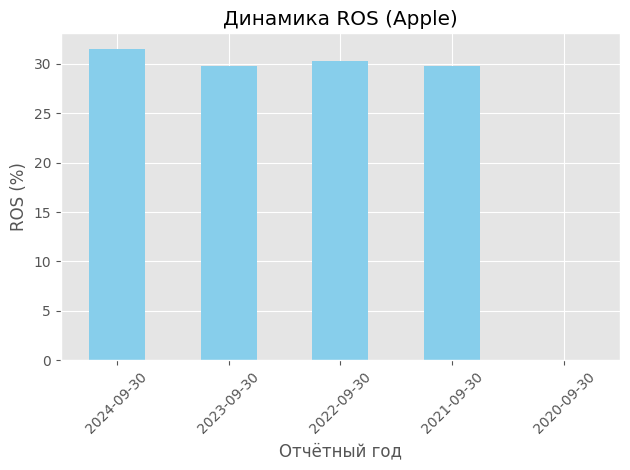

In [4]:
df["ROS"].plot(kind="bar", title="Динамика ROS (Apple)", color="skyblue")
plt.ylabel("ROS (%)")
plt.xlabel("Отчётный год")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


In [ ]:
# Посмотрим, какие есть названия строк/показателей
# df.columns.to_list()


['Tax Effect Of Unusual Items',
 'Tax Rate For Calcs',
 'Normalized EBITDA',
 'Net Income From Continuing Operation Net Minority Interest',
 'Reconciled Depreciation',
 'Reconciled Cost Of Revenue',
 'EBITDA',
 'EBIT',
 'Net Interest Income',
 'Interest Expense',
 'Interest Income',
 'Normalized Income',
 'Net Income From Continuing And Discontinued Operation',
 'Total Expenses',
 'Total Operating Income As Reported',
 'Diluted Average Shares',
 'Basic Average Shares',
 'Diluted EPS',
 'Basic EPS',
 'Diluted NI Availto Com Stockholders',
 'Net Income Common Stockholders',
 'Net Income',
 'Net Income Including Noncontrolling Interests',
 'Net Income Continuous Operations',
 'Tax Provision',
 'Pretax Income',
 'Other Income Expense',
 'Other Non Operating Income Expenses',
 'Net Non Operating Interest Income Expense',
 'Interest Expense Non Operating',
 'Interest Income Non Operating',
 'Operating Income',
 'Operating Expense',
 'Research And Development',
 'Selling General And Administr

In [ ]:
# Загружаем данные
aapl = yf.Ticker("AAPL")

# Получаем баланс
balance = aapl.balance_sheet

# Транспонируем и смотрим, что там
balance = balance.T
balance.head() # отладка . можно убрать


,Treasury Shares Number,Ordinary Shares Number,Share Issued,Net Debt,Total Debt,Tangible Book Value,Invested Capital,Working Capital,Net Tangible Assets,Capital Lease Obligations,...,Other Current Assets,Inventory,Receivables,Other Receivables,Accounts Receivable,Cash Cash Equivalents And Short Term Investments,Other Short Term Investments,Cash And Cash Equivalents,Cash Equivalents,Cash Financial
2024-09-30,NaN,15116786000.0,15116786000.0,76686000000.0,106629000000.0,56950000000.0,163579000000.0,-23405000000.0,56950000000.0,NaN,...,14287000000.0,7286000000.0,66243000000.0,32833000000.0,33410000000.0,65171000000.0,35228000000.0,29943000000.0,2744000000.0,27199000000.0
2023-09-30,0.0,15550061000.0,15550061000.0,81123000000.0,111088000000.0,62146000000.0,173234000000.0,-1742000000.0,62146000000.0,12842000000.0,...,14695000000.0,6331000000.0,60985000000.0,31477000000.0,29508000000.0,61555000000.0,31590000000.0,29965000000.0,1606000000.0,28359000000.0
2022-09-30,NaN,15943425000.0,15943425000.0,96423000000.0,132480000000.0,50672000000.0,170741000000.0,-18577000000.0,50672000000.0,12411000000.0,...,21223000000.0,4946000000.0,60932000000.0,32748000000.0,28184000000.0,48304000000.0,24658000000.0,23646000000.0,5100000000.0,18546000000.0
2021-09-30,NaN,16426786000.0,16426786000.0,89779000000.0,136522000000.0,63090000000.0,187809000000.0,9355000000.0,63090000000.0,11803000000.0,...,14111000000.0,6580000000.0,51506000000.0,25228000000.0,26278000000.0,62639000000.0,27699000000.0,34940000000.0,17635000000.0,17305000000.0
2020-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9842000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# balance.columns.to_list()


['Treasury Shares Number',
 'Ordinary Shares Number',
 'Share Issued',
 'Net Debt',
 'Total Debt',
 'Tangible Book Value',
 'Invested Capital',
 'Working Capital',
 'Net Tangible Assets',
 'Capital Lease Obligations',
 'Common Stock Equity',
 'Total Capitalization',
 'Total Equity Gross Minority Interest',
 'Stockholders Equity',
 'Gains Losses Not Affecting Retained Earnings',
 'Other Equity Adjustments',
 'Retained Earnings',
 'Capital Stock',
 'Common Stock',
 'Total Liabilities Net Minority Interest',
 'Total Non Current Liabilities Net Minority Interest',
 'Other Non Current Liabilities',
 'Tradeand Other Payables Non Current',
 'Long Term Debt And Capital Lease Obligation',
 'Long Term Capital Lease Obligation',
 'Long Term Debt',
 'Current Liabilities',
 'Other Current Liabilities',
 'Current Deferred Liabilities',
 'Current Deferred Revenue',
 'Current Debt And Capital Lease Obligation',
 'Current Capital Lease Obligation',
 'Current Debt',
 'Other Current Borrowings',
 'Commer

In [8]:
# Смотрим поквартальный баланс
quarterly_balance = aapl.quarterly_balance_sheet.T
quarterly_balance.columns.to_list()


['Treasury Shares Number',
 'Ordinary Shares Number',
 'Share Issued',
 'Net Debt',
 'Total Debt',
 'Tangible Book Value',
 'Invested Capital',
 'Working Capital',
 'Net Tangible Assets',
 'Capital Lease Obligations',
 'Common Stock Equity',
 'Total Capitalization',
 'Total Equity Gross Minority Interest',
 'Stockholders Equity',
 'Gains Losses Not Affecting Retained Earnings',
 'Other Equity Adjustments',
 'Retained Earnings',
 'Capital Stock',
 'Common Stock',
 'Total Liabilities Net Minority Interest',
 'Total Non Current Liabilities Net Minority Interest',
 'Other Non Current Liabilities',
 'Tradeand Other Payables Non Current',
 'Long Term Debt And Capital Lease Obligation',
 'Long Term Capital Lease Obligation',
 'Long Term Debt',
 'Current Liabilities',
 'Other Current Liabilities',
 'Current Deferred Liabilities',
 'Current Deferred Revenue',
 'Current Debt And Capital Lease Obligation',
 'Current Capital Lease Obligation',
 'Current Debt',
 'Other Current Borrowings',
 'Commer

In [10]:
# Подготовим упрощённые переменные
cash = balance["Cash And Cash Equivalents"]
receivables = balance["Receivables"]
inventory = balance["Inventory"]
working_capital = balance["Working Capital"]

# Приблизим current liabilities
current_liabilities = (cash + receivables + inventory) - working_capital

# Расчёт ликвидности
current_ratio = (cash + receivables + inventory) / current_liabilities
quick_ratio = (cash + receivables) / current_liabilities
absolute_ratio = cash / current_liabilities

# Покажем
current_ratio, quick_ratio, absolute_ratio



(2024-09-30     0.81553
 2023-09-30    0.982408
 2022-09-30    0.828151
 2021-09-30    1.111807
 2020-09-30         NaN
 dtype: object,
 2024-09-30    0.758104
 2023-09-30    0.918473
 2022-09-30    0.782398
 2021-09-30    1.033166
 2020-09-30         NaN
 dtype: object,
 2024-09-30       0.236
 2023-09-30    0.302606
 2022-09-30     0.21874
 2021-09-30    0.417588
 2020-09-30         NaN
 dtype: object)

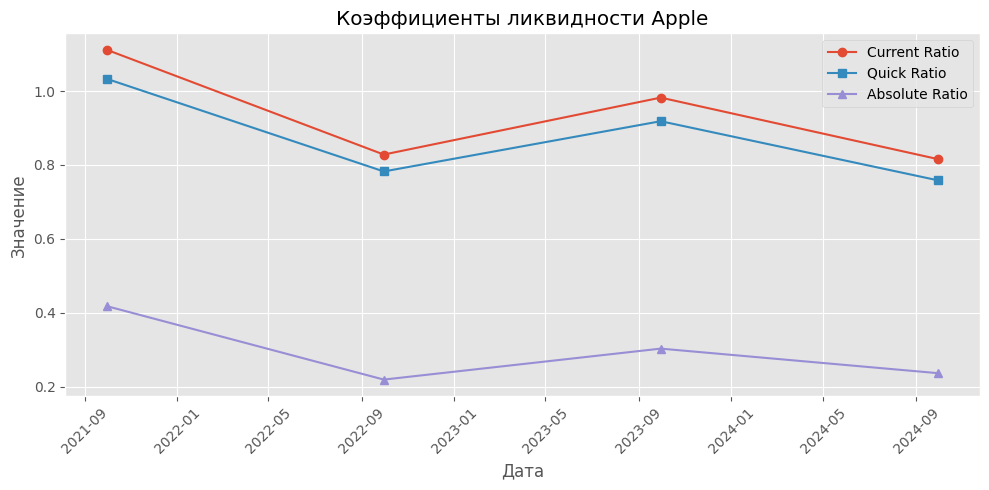

In [11]:
# Построим график
plt.figure(figsize=(10, 5))
plt.plot(current_ratio, label="Current Ratio", marker="o")
plt.plot(quick_ratio, label="Quick Ratio", marker="s")
plt.plot(absolute_ratio, label="Absolute Ratio", marker="^")

# Оформление
plt.title("Коэффициенты ликвидности Apple")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
df_final = pd.DataFrame({
    "ROS": df["ROS"],
    "Current Ratio": current_ratio,
    "Quick Ratio": quick_ratio,
    "Absolute Ratio": absolute_ratio
})
df_final.to_csv("../data/metrics_AAPL.csv")


## Сравнительный анализ: AAPL, MSFT, TSLA

In [13]:
tickers = ["AAPL", "MSFT", "TSLA"]
results = []

for ticker in tickers:
    stock = yf.Ticker(ticker)
    financials = stock.financials.T
    balance = stock.balance_sheet.T

    try:
        revenue = financials["Total Revenue"]
        op_income = financials["Operating Income"]
        ros = (op_income / revenue * 100).dropna()

        cash = balance["Cash And Cash Equivalents"]
        receivables = balance["Receivables"]
        inventory = balance["Inventory"]
        working_capital = balance["Working Capital"]

        current_liabilities = (cash + receivables + inventory) - working_capital

        current_ratio = (cash + receivables + inventory) / current_liabilities
        quick_ratio = (cash + receivables) / current_liabilities
        absolute_ratio = cash / current_liabilities

        for date in ros.index:
            results.append({
                "ticker": ticker,
                "date": date,
                "ROS": ros[date],
                "Current Ratio": current_ratio.get(date),
                "Quick Ratio": quick_ratio.get(date),
                "Absolute Ratio": absolute_ratio.get(date)
            })
    except Exception as e:
        print(f"Ошибка для {ticker}: {e}")
